In [1]:
import joblib 
from utils.utils_2 import plot_most_accurate_window_angle_lstm, plot_most_accurate_window_lstm, visualize_attention_single_angle

In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import torch.optim as optim
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
scaler_X = MinMaxScaler()
dfs = pd.read_csv("../data/features.csv", index_col="Time_[s]")
targets = pd.read_csv("../data/targets.csv", index_col=False)
# df = dfs[dfs["Experiment_ID"]==2].drop(columns=["Experiment_ID"])
col = "Angle[degree]ORDistance[mm]"

scaler = MinMaxScaler(feature_range=(0, 1))
targets[col] = scaler.fit_transform(targets[[col]])
# See the first few rows
# bend_columns = [col for col in dfs.columns if 'BEND' in col]
# bend_columns.insert(0,'Experiment_ID')
# dfs = dfs.loc[:, bend_columns]
target = targets[targets["Experiment_ID"]==2]

In [3]:
groups_y = []
max_len_y = targets.groupby("Experiment_ID").size().max()
num_target_features = targets.shape[1] - 1  # exclude Experiment_ID

for exp_id, group in targets.groupby("Experiment_ID"):
    values = group.drop(columns=["Experiment_ID"]).values  # (len_group, num_target_features)
    
    # Pad with NaN
    padded = np.full((max_len_y, num_target_features), np.nan)
    padded[:values.shape[0], :] = values
    groups_y.append(padded)

# Final y: (num_experiments, max_len, num_target_features)
y = np.array(groups_y, dtype=float)

# Replace NaN with 0
Y = np.nan_to_num(y, nan=0.0)



groups = []
max_len = dfs.groupby("Experiment_ID").size().max()  # longest experiment
num_features = dfs.shape[1] - 1  # exclude Experiment_ID

for exp_id, group in dfs.groupby("Experiment_ID"):
    features = group.drop(columns=["Experiment_ID"]).values
    
    # Pad with NaN (or zeros) to match max_len
    padded = np.full((max_len, num_features), np.nan)  
    padded[:features.shape[0], :] = features
    groups.append(padded)


X = np.array(groups, dtype=float)
X = np.nan_to_num(X, nan=0.0)[:5,:,:]
Y = np.nan_to_num(y, nan=0.0)[:5,:,3:4]
print("Shape:", X.shape, Y.shape)  

Shape: (5, 1743, 17) (5, 47, 1)


In [5]:
from torch.utils.data import Dataset
# -----------------------------
# Custom Dataset
# -----------------------------
class SequenceDataset(Dataset):
    def __init__(self, X, Y):
        """
        X: torch.Tensor of shape (num_samples, seq_len, num_features)
        Y: torch.Tensor of shape (num_samples, num_angles, 1)
        """
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]


Training for angle 0...
Angle 0 | Epoch 001 | Loss 0.088707
Angle 0 | Epoch 002 | Loss 0.009841
Angle 0 | Epoch 003 | Loss 0.003262
Angle 0 | Epoch 004 | Loss 0.002307
Angle 0 | Epoch 005 | Loss 0.001069
Angle 0 | Epoch 006 | Loss 0.001686
Angle 0 | Epoch 007 | Loss 0.000838
Angle 0 | Epoch 008 | Loss 0.001036
Angle 0 | Epoch 009 | Loss 0.000729
Angle 0 | Epoch 010 | Loss 0.000783
Most important window for angle 0: 1


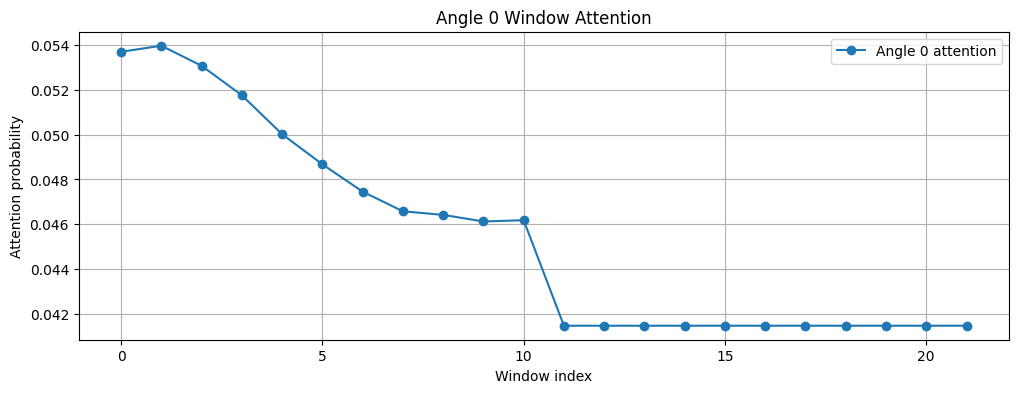


Training for angle 1...
Angle 1 | Epoch 001 | Loss 0.063834
Angle 1 | Epoch 002 | Loss 0.015442
Angle 1 | Epoch 003 | Loss 0.005896
Angle 1 | Epoch 004 | Loss 0.002170
Angle 1 | Epoch 005 | Loss 0.002243
Angle 1 | Epoch 006 | Loss 0.001493
Angle 1 | Epoch 007 | Loss 0.001028
Angle 1 | Epoch 008 | Loss 0.000480
Angle 1 | Epoch 009 | Loss 0.000943
Angle 1 | Epoch 010 | Loss 0.000842
Most important window for angle 1: 0


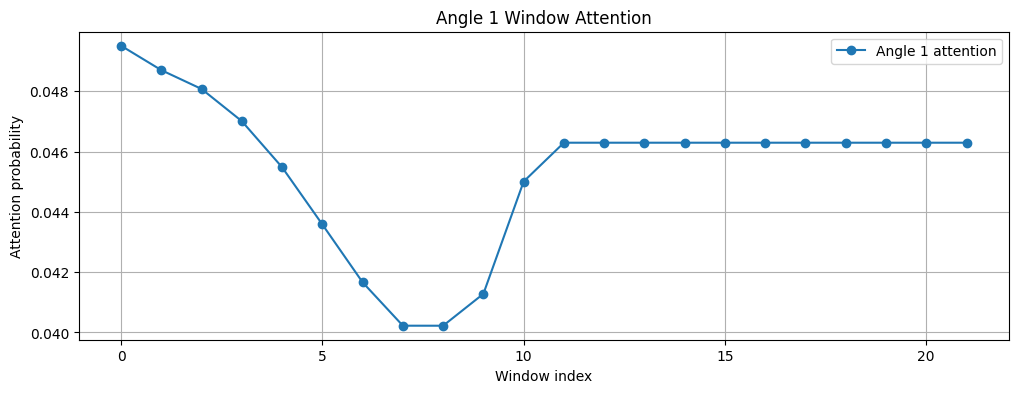


Training for angle 2...
Angle 2 | Epoch 001 | Loss 0.057495
Angle 2 | Epoch 002 | Loss 0.011385
Angle 2 | Epoch 003 | Loss 0.002773
Angle 2 | Epoch 004 | Loss 0.001746
Angle 2 | Epoch 005 | Loss 0.001081
Angle 2 | Epoch 006 | Loss 0.000876
Angle 2 | Epoch 007 | Loss 0.001251
Angle 2 | Epoch 008 | Loss 0.000568
Angle 2 | Epoch 009 | Loss 0.000152
Angle 2 | Epoch 010 | Loss 0.000419
Most important window for angle 2: 10


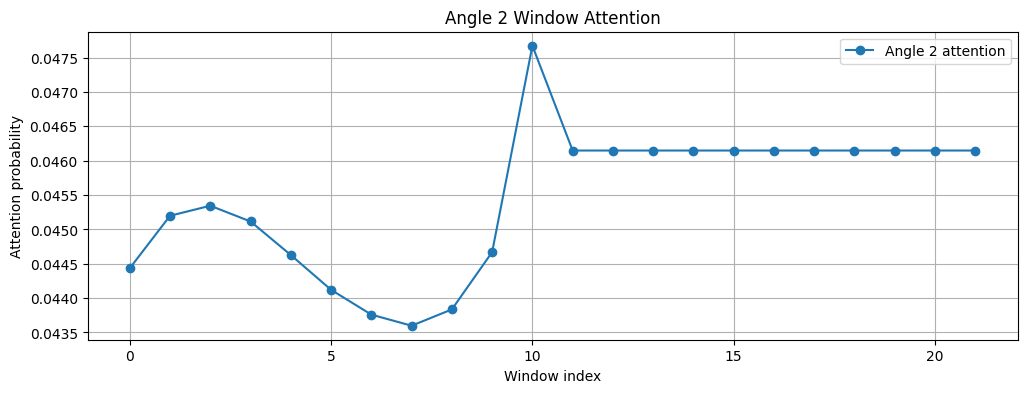


Training for angle 3...
Angle 3 | Epoch 001 | Loss 0.034498
Angle 3 | Epoch 002 | Loss 0.010179
Angle 3 | Epoch 003 | Loss 0.004617
Angle 3 | Epoch 004 | Loss 0.001117
Angle 3 | Epoch 005 | Loss 0.001054
Angle 3 | Epoch 006 | Loss 0.000654
Angle 3 | Epoch 007 | Loss 0.000624
Angle 3 | Epoch 008 | Loss 0.000574
Angle 3 | Epoch 009 | Loss 0.000642
Angle 3 | Epoch 010 | Loss 0.000248
Most important window for angle 3: 11


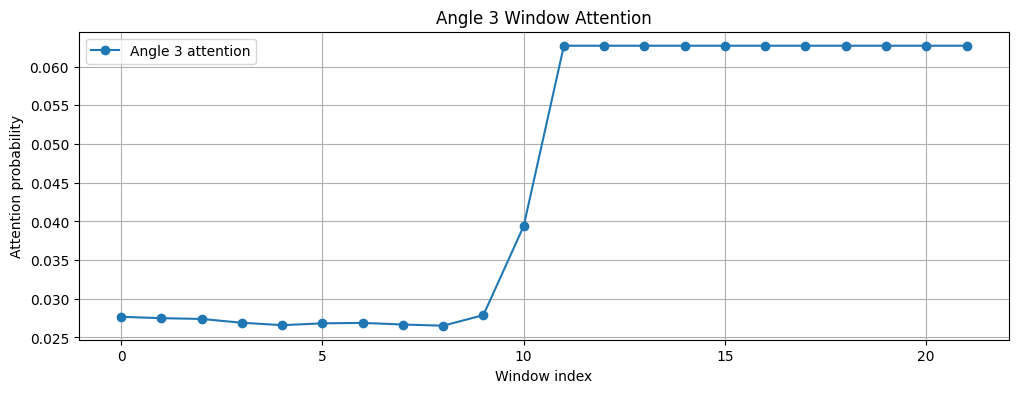


Training for angle 4...
Angle 4 | Epoch 001 | Loss 0.151200
Angle 4 | Epoch 002 | Loss 0.012325
Angle 4 | Epoch 003 | Loss 0.004582
Angle 4 | Epoch 004 | Loss 0.002318
Angle 4 | Epoch 005 | Loss 0.001425
Angle 4 | Epoch 006 | Loss 0.000806
Angle 4 | Epoch 007 | Loss 0.000313
Angle 4 | Epoch 008 | Loss 0.000283
Angle 4 | Epoch 009 | Loss 0.000317
Angle 4 | Epoch 010 | Loss 0.000321
Most important window for angle 4: 3


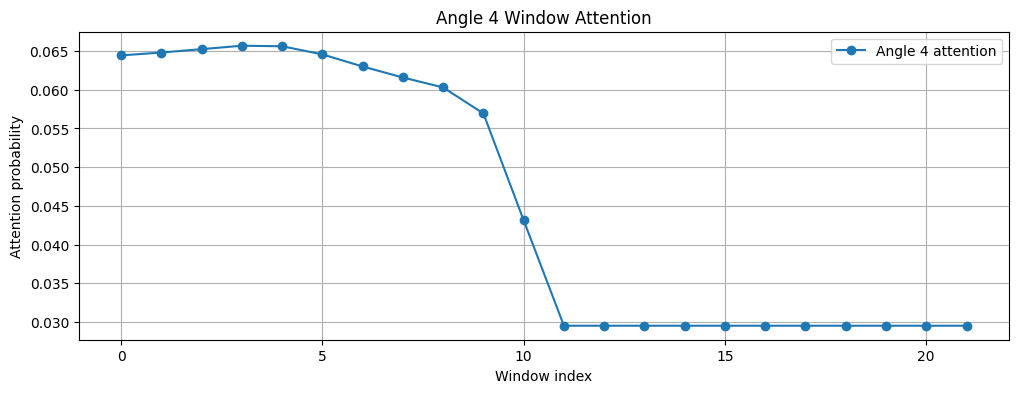


Training for angle 5...
Angle 5 | Epoch 001 | Loss 0.227189
Angle 5 | Epoch 002 | Loss 0.020006
Angle 5 | Epoch 003 | Loss 0.012157
Angle 5 | Epoch 004 | Loss 0.004211
Angle 5 | Epoch 005 | Loss 0.001989
Angle 5 | Epoch 006 | Loss 0.002248
Angle 5 | Epoch 007 | Loss 0.001524
Angle 5 | Epoch 008 | Loss 0.000302
Angle 5 | Epoch 009 | Loss 0.000980
Angle 5 | Epoch 010 | Loss 0.000675
Most important window for angle 5: 20


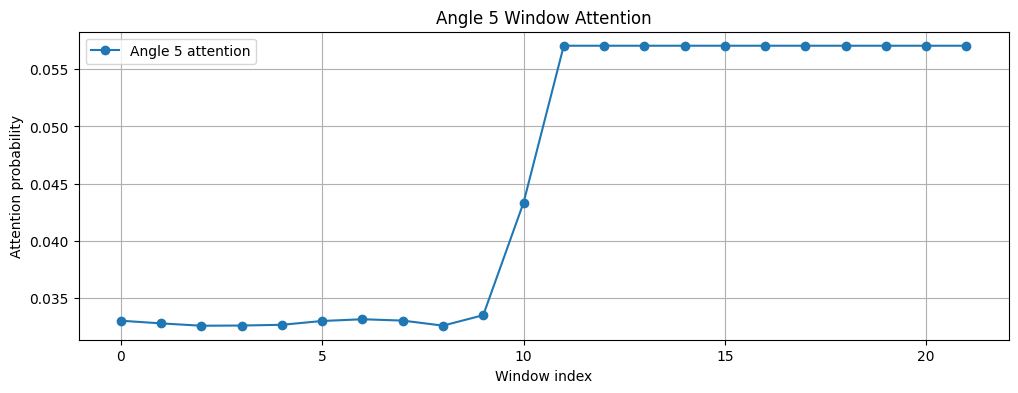


Training for angle 6...
Angle 6 | Epoch 001 | Loss 0.027127
Angle 6 | Epoch 002 | Loss 0.002330
Angle 6 | Epoch 003 | Loss 0.000567
Angle 6 | Epoch 004 | Loss 0.000991
Angle 6 | Epoch 005 | Loss 0.001793
Angle 6 | Epoch 006 | Loss 0.001028
Angle 6 | Epoch 007 | Loss 0.000801
Angle 6 | Epoch 008 | Loss 0.000846
Angle 6 | Epoch 009 | Loss 0.002194
Angle 6 | Epoch 010 | Loss 0.001672
Most important window for angle 6: 0


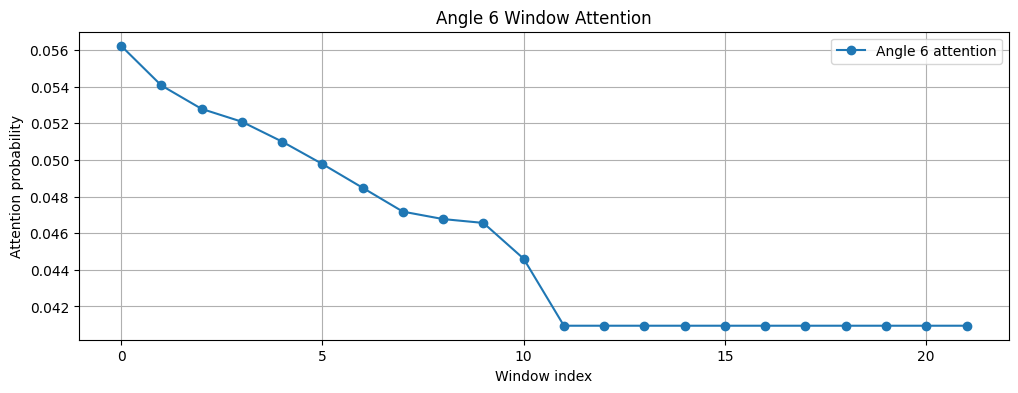


Training for angle 7...
Angle 7 | Epoch 001 | Loss 0.114984
Angle 7 | Epoch 002 | Loss 0.016981
Angle 7 | Epoch 003 | Loss 0.006961
Angle 7 | Epoch 004 | Loss 0.009215
Angle 7 | Epoch 005 | Loss 0.001251
Angle 7 | Epoch 006 | Loss 0.002413
Angle 7 | Epoch 007 | Loss 0.001105
Angle 7 | Epoch 008 | Loss 0.000672
Angle 7 | Epoch 009 | Loss 0.000632
Angle 7 | Epoch 010 | Loss 0.000572
Most important window for angle 7: 11


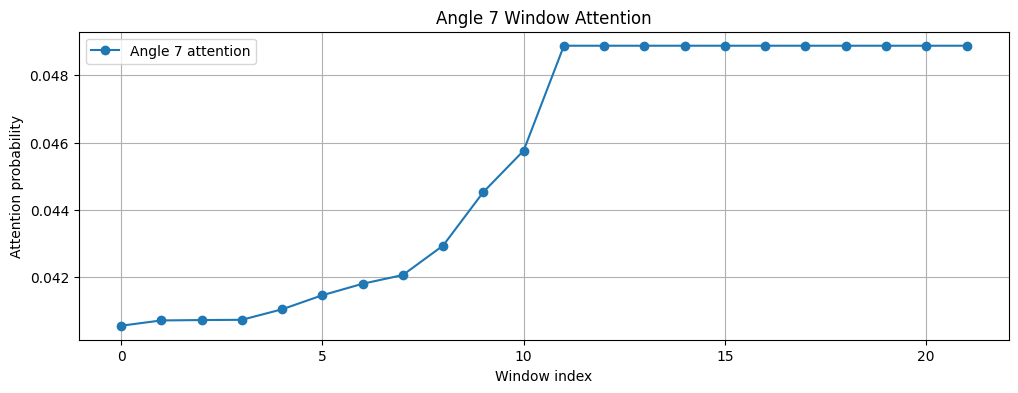


Training for angle 8...
Angle 8 | Epoch 001 | Loss 0.040819
Angle 8 | Epoch 002 | Loss 0.003938
Angle 8 | Epoch 003 | Loss 0.001848
Angle 8 | Epoch 004 | Loss 0.000749
Angle 8 | Epoch 005 | Loss 0.000304
Angle 8 | Epoch 006 | Loss 0.000510
Angle 8 | Epoch 007 | Loss 0.000654
Angle 8 | Epoch 008 | Loss 0.001247
Angle 8 | Epoch 009 | Loss 0.000747
Angle 8 | Epoch 010 | Loss 0.000386
Most important window for angle 8: 20


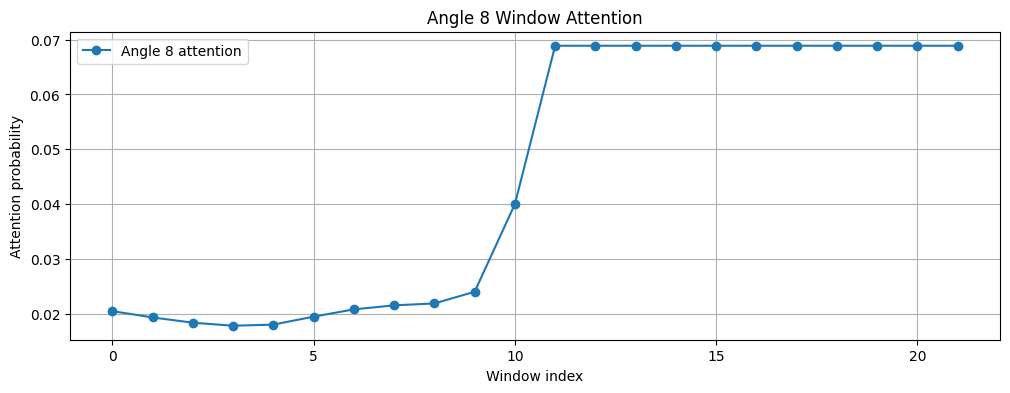


Training for angle 9...
Angle 9 | Epoch 001 | Loss 0.034918
Angle 9 | Epoch 002 | Loss 0.007887
Angle 9 | Epoch 003 | Loss 0.004432
Angle 9 | Epoch 004 | Loss 0.002215
Angle 9 | Epoch 005 | Loss 0.001093
Angle 9 | Epoch 006 | Loss 0.000322
Angle 9 | Epoch 007 | Loss 0.000187
Angle 9 | Epoch 008 | Loss 0.000175
Angle 9 | Epoch 009 | Loss 0.000109
Angle 9 | Epoch 010 | Loss 0.000263
Most important window for angle 9: 11


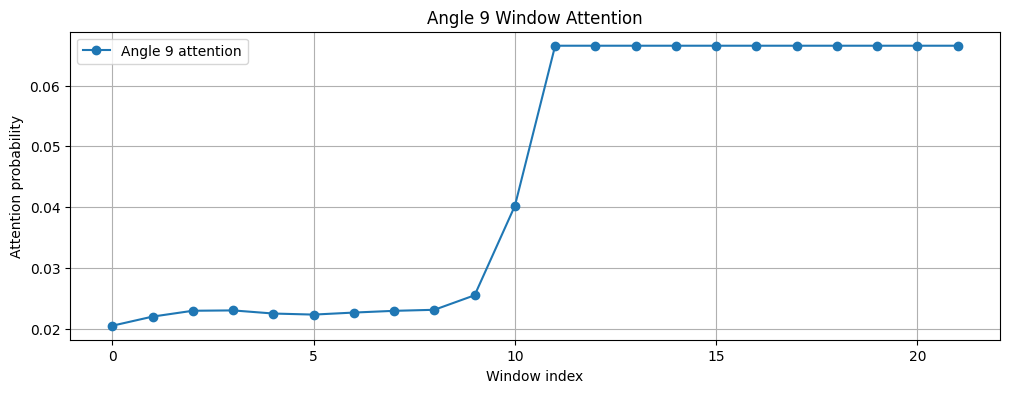


Training for angle 10...
Angle 10 | Epoch 001 | Loss 0.038383
Angle 10 | Epoch 002 | Loss 0.007771
Angle 10 | Epoch 003 | Loss 0.003466
Angle 10 | Epoch 004 | Loss 0.001548
Angle 10 | Epoch 005 | Loss 0.001189
Angle 10 | Epoch 006 | Loss 0.000718
Angle 10 | Epoch 007 | Loss 0.000338
Angle 10 | Epoch 008 | Loss 0.000315
Angle 10 | Epoch 009 | Loss 0.000401
Angle 10 | Epoch 010 | Loss 0.000071
Most important window for angle 10: 20


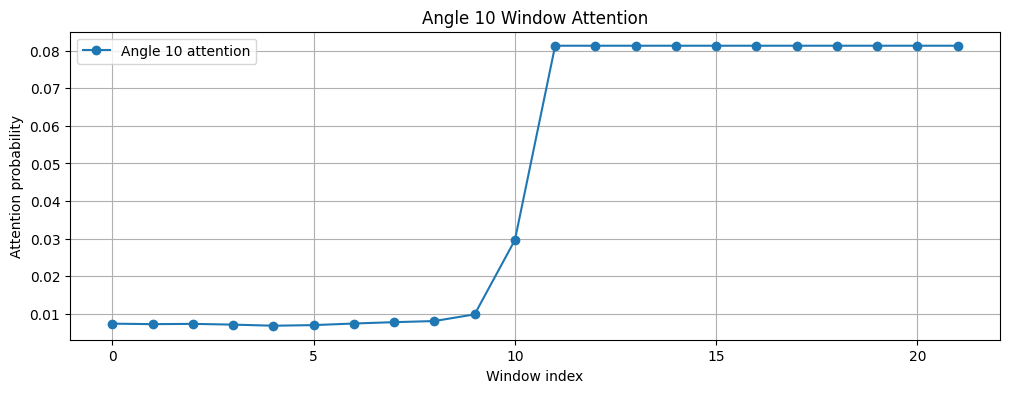


Training for angle 11...
Angle 11 | Epoch 001 | Loss 0.036223
Angle 11 | Epoch 002 | Loss 0.014197
Angle 11 | Epoch 003 | Loss 0.006693
Angle 11 | Epoch 004 | Loss 0.004924
Angle 11 | Epoch 005 | Loss 0.002401
Angle 11 | Epoch 006 | Loss 0.001063
Angle 11 | Epoch 007 | Loss 0.000572
Angle 11 | Epoch 008 | Loss 0.000554
Angle 11 | Epoch 009 | Loss 0.000234
Angle 11 | Epoch 010 | Loss 0.000105
Most important window for angle 11: 11


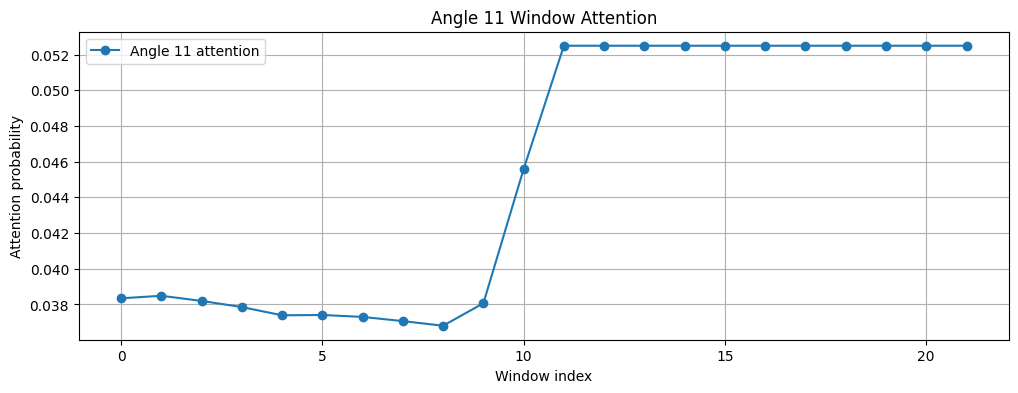


Training for angle 12...
Angle 12 | Epoch 001 | Loss 0.045290
Angle 12 | Epoch 002 | Loss 0.009481
Angle 12 | Epoch 003 | Loss 0.004371
Angle 12 | Epoch 004 | Loss 0.002154
Angle 12 | Epoch 005 | Loss 0.001111
Angle 12 | Epoch 006 | Loss 0.000574
Angle 12 | Epoch 007 | Loss 0.000305
Angle 12 | Epoch 008 | Loss 0.000064
Angle 12 | Epoch 009 | Loss 0.000052
Angle 12 | Epoch 010 | Loss 0.000114
Most important window for angle 12: 20


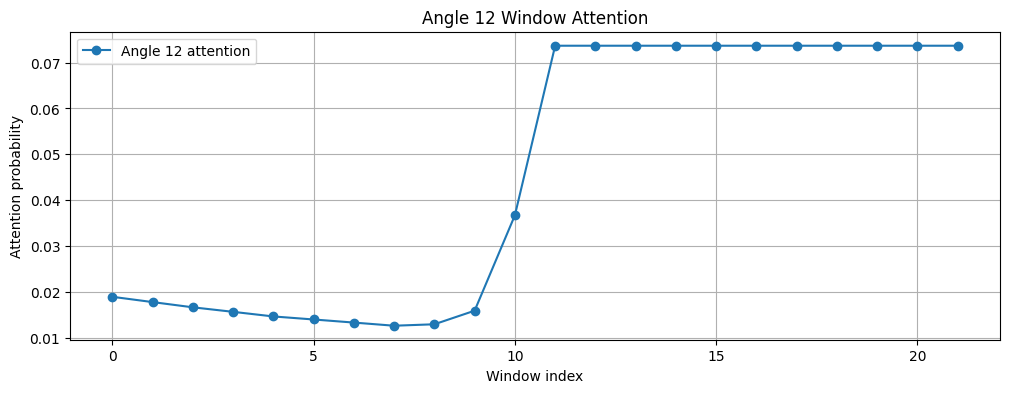


Training for angle 13...
Angle 13 | Epoch 001 | Loss 0.080574
Angle 13 | Epoch 002 | Loss 0.012607
Angle 13 | Epoch 003 | Loss 0.003757
Angle 13 | Epoch 004 | Loss 0.002353
Angle 13 | Epoch 005 | Loss 0.001873
Angle 13 | Epoch 006 | Loss 0.001540
Angle 13 | Epoch 007 | Loss 0.000554
Angle 13 | Epoch 008 | Loss 0.000211
Angle 13 | Epoch 009 | Loss 0.000283
Angle 13 | Epoch 010 | Loss 0.000161
Most important window for angle 13: 11


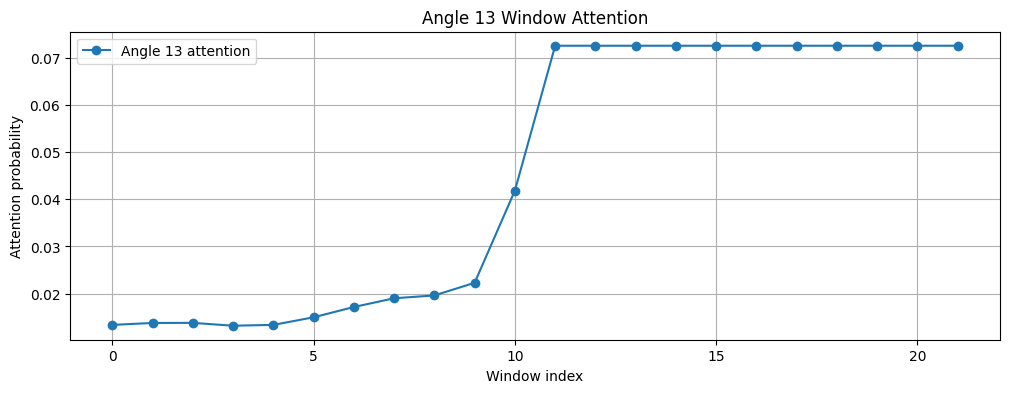


Training for angle 14...
Angle 14 | Epoch 001 | Loss 0.112635
Angle 14 | Epoch 002 | Loss 0.005275
Angle 14 | Epoch 003 | Loss 0.000859
Angle 14 | Epoch 004 | Loss 0.000948
Angle 14 | Epoch 005 | Loss 0.001107
Angle 14 | Epoch 006 | Loss 0.000257
Angle 14 | Epoch 007 | Loss 0.000123
Angle 14 | Epoch 008 | Loss 0.000609
Angle 14 | Epoch 009 | Loss 0.000875
Angle 14 | Epoch 010 | Loss 0.000671
Most important window for angle 14: 11


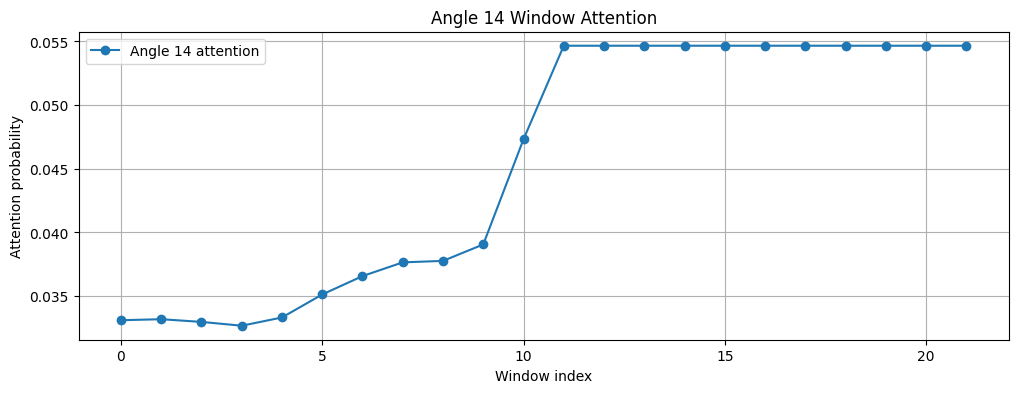


Training for angle 15...
Angle 15 | Epoch 001 | Loss 0.096243
Angle 15 | Epoch 002 | Loss 0.007539
Angle 15 | Epoch 003 | Loss 0.003471
Angle 15 | Epoch 004 | Loss 0.001691
Angle 15 | Epoch 005 | Loss 0.000635
Angle 15 | Epoch 006 | Loss 0.000436
Angle 15 | Epoch 007 | Loss 0.000549
Angle 15 | Epoch 008 | Loss 0.000285
Angle 15 | Epoch 009 | Loss 0.000142
Angle 15 | Epoch 010 | Loss 0.000186
Most important window for angle 15: 11


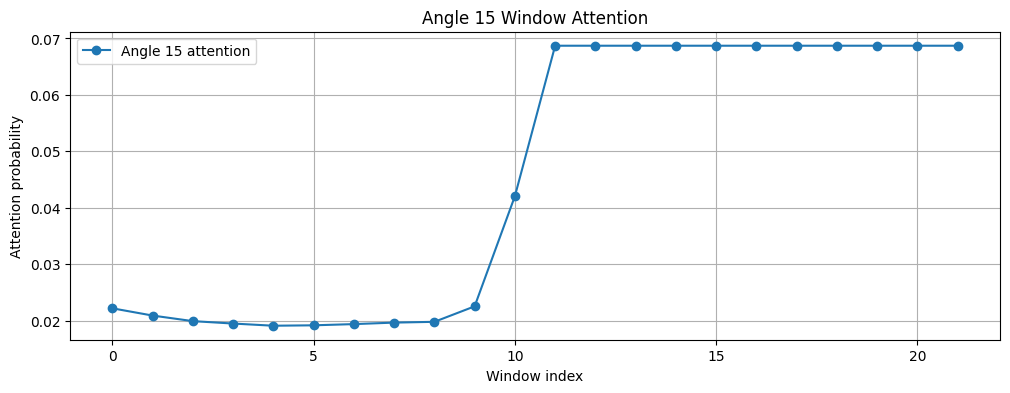


Training for angle 16...
Angle 16 | Epoch 001 | Loss 0.144358
Angle 16 | Epoch 002 | Loss 0.015636
Angle 16 | Epoch 003 | Loss 0.009763
Angle 16 | Epoch 004 | Loss 0.006296
Angle 16 | Epoch 005 | Loss 0.001168
Angle 16 | Epoch 006 | Loss 0.001914
Angle 16 | Epoch 007 | Loss 0.000513
Angle 16 | Epoch 008 | Loss 0.000411
Angle 16 | Epoch 009 | Loss 0.000320
Angle 16 | Epoch 010 | Loss 0.000234
Most important window for angle 16: 11


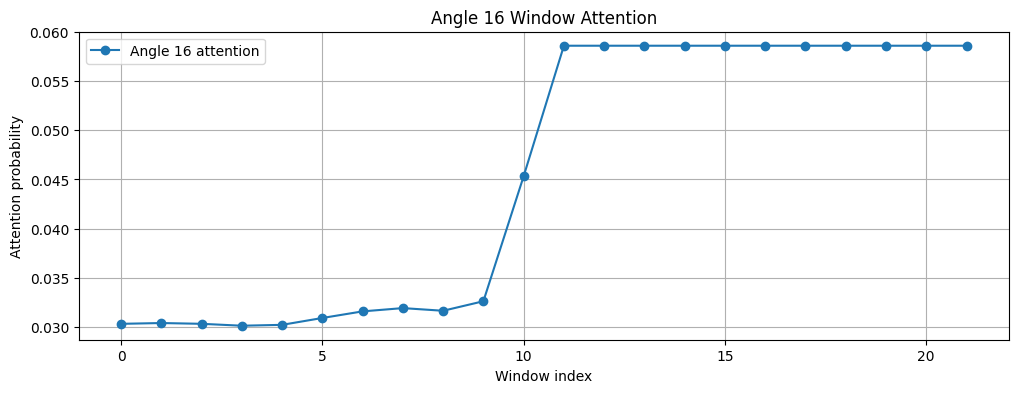


Training for angle 17...
Angle 17 | Epoch 001 | Loss 0.067980
Angle 17 | Epoch 002 | Loss 0.019991
Angle 17 | Epoch 003 | Loss 0.008593
Angle 17 | Epoch 004 | Loss 0.003254
Angle 17 | Epoch 005 | Loss 0.003211
Angle 17 | Epoch 006 | Loss 0.002645
Angle 17 | Epoch 007 | Loss 0.000977
Angle 17 | Epoch 008 | Loss 0.000516
Angle 17 | Epoch 009 | Loss 0.000549
Angle 17 | Epoch 010 | Loss 0.000389
Most important window for angle 17: 9


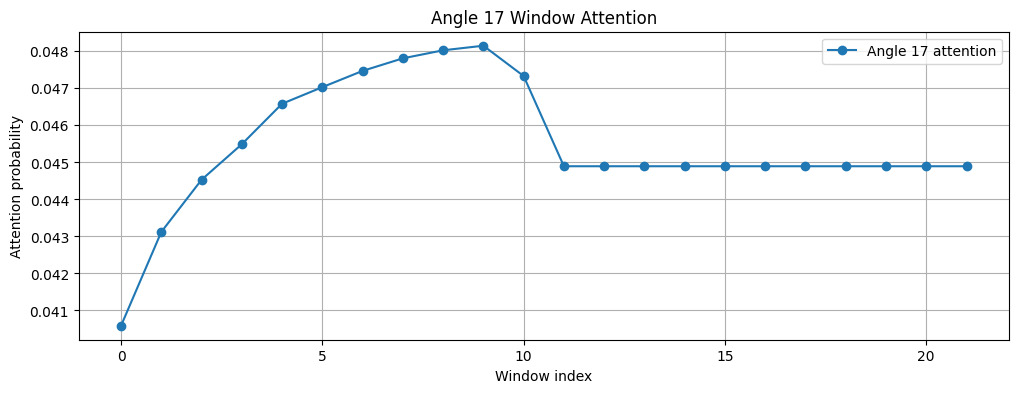


Training for angle 18...
Angle 18 | Epoch 001 | Loss 0.058399
Angle 18 | Epoch 002 | Loss 0.007867
Angle 18 | Epoch 003 | Loss 0.002995
Angle 18 | Epoch 004 | Loss 0.003094
Angle 18 | Epoch 005 | Loss 0.000887
Angle 18 | Epoch 006 | Loss 0.000658
Angle 18 | Epoch 007 | Loss 0.000460
Angle 18 | Epoch 008 | Loss 0.000206
Angle 18 | Epoch 009 | Loss 0.000067
Angle 18 | Epoch 010 | Loss 0.000139
Most important window for angle 18: 8


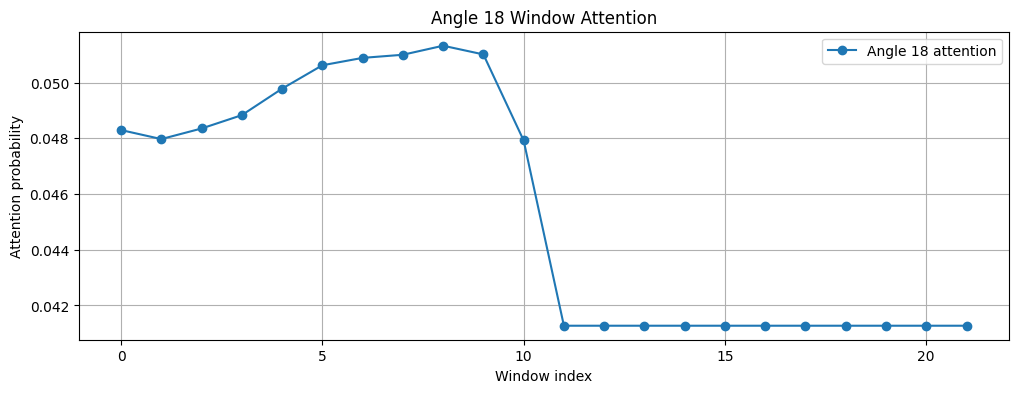


Training for angle 19...
Angle 19 | Epoch 001 | Loss 0.067558
Angle 19 | Epoch 002 | Loss 0.021748
Angle 19 | Epoch 003 | Loss 0.007551
Angle 19 | Epoch 004 | Loss 0.004830
Angle 19 | Epoch 005 | Loss 0.003708
Angle 19 | Epoch 006 | Loss 0.001041
Angle 19 | Epoch 007 | Loss 0.000438
Angle 19 | Epoch 008 | Loss 0.000247
Angle 19 | Epoch 009 | Loss 0.000289
Angle 19 | Epoch 010 | Loss 0.000113
Most important window for angle 19: 21


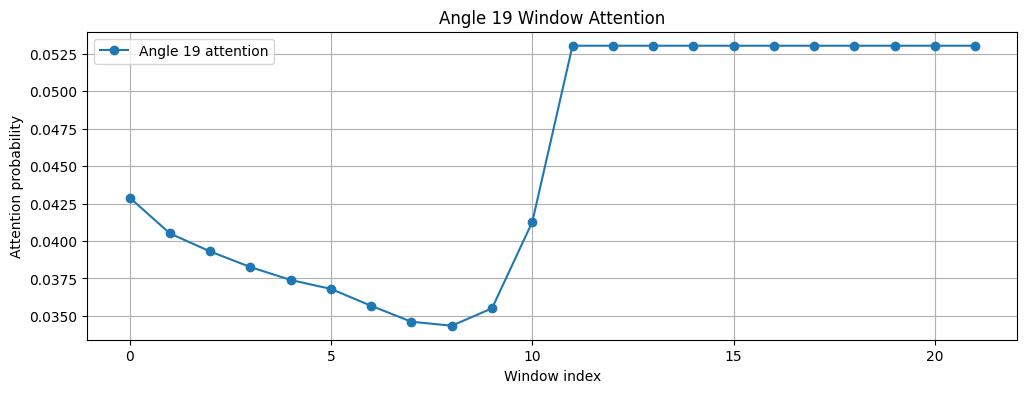


Training for angle 20...
Angle 20 | Epoch 001 | Loss 0.122895
Angle 20 | Epoch 002 | Loss 0.016847
Angle 20 | Epoch 003 | Loss 0.006407
Angle 20 | Epoch 004 | Loss 0.002464
Angle 20 | Epoch 005 | Loss 0.002942
Angle 20 | Epoch 006 | Loss 0.002601
Angle 20 | Epoch 007 | Loss 0.001137
Angle 20 | Epoch 008 | Loss 0.000822
Angle 20 | Epoch 009 | Loss 0.000546
Angle 20 | Epoch 010 | Loss 0.000338
Most important window for angle 20: 7


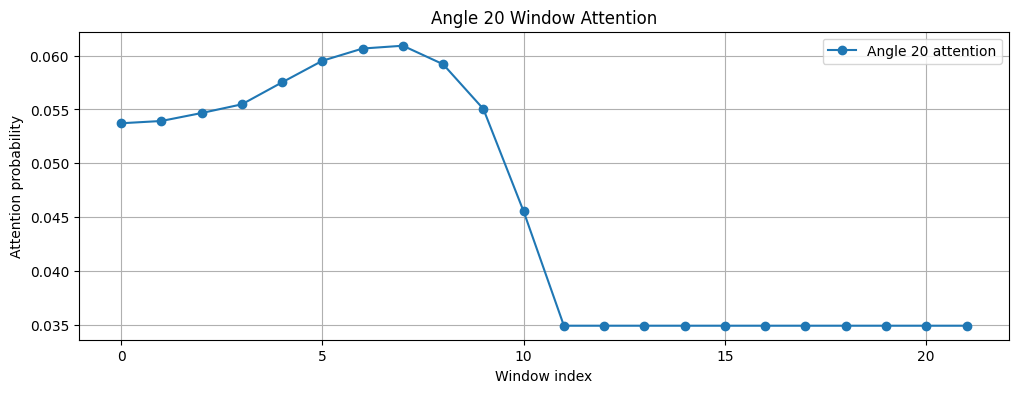


Training for angle 21...
Angle 21 | Epoch 001 | Loss 0.080732
Angle 21 | Epoch 002 | Loss 0.017058
Angle 21 | Epoch 003 | Loss 0.003803
Angle 21 | Epoch 004 | Loss 0.002011
Angle 21 | Epoch 005 | Loss 0.002639
Angle 21 | Epoch 006 | Loss 0.000307
Angle 21 | Epoch 007 | Loss 0.000201
Angle 21 | Epoch 008 | Loss 0.000176
Angle 21 | Epoch 009 | Loss 0.000150
Angle 21 | Epoch 010 | Loss 0.000079
Most important window for angle 21: 11


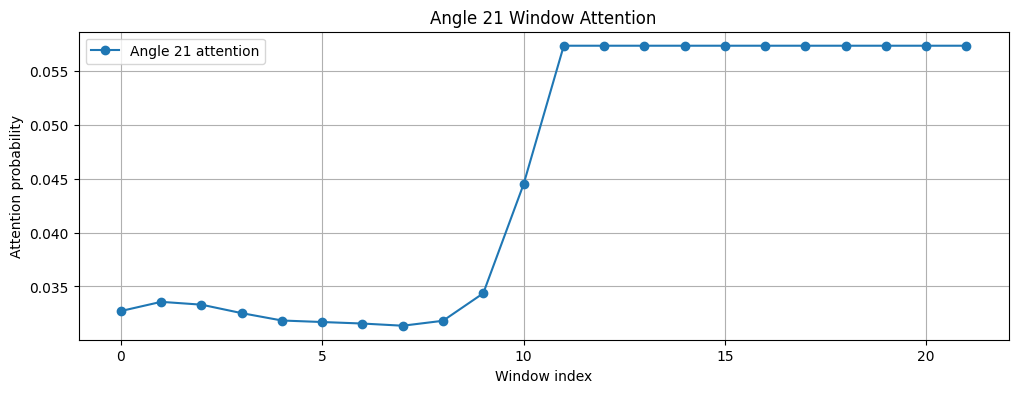


Training for angle 22...
Angle 22 | Epoch 001 | Loss 0.191792
Angle 22 | Epoch 002 | Loss 0.019336
Angle 22 | Epoch 003 | Loss 0.009353
Angle 22 | Epoch 004 | Loss 0.006963
Angle 22 | Epoch 005 | Loss 0.004721
Angle 22 | Epoch 006 | Loss 0.001582
Angle 22 | Epoch 007 | Loss 0.001562
Angle 22 | Epoch 008 | Loss 0.000964
Angle 22 | Epoch 009 | Loss 0.000515
Angle 22 | Epoch 010 | Loss 0.000235
Most important window for angle 22: 11


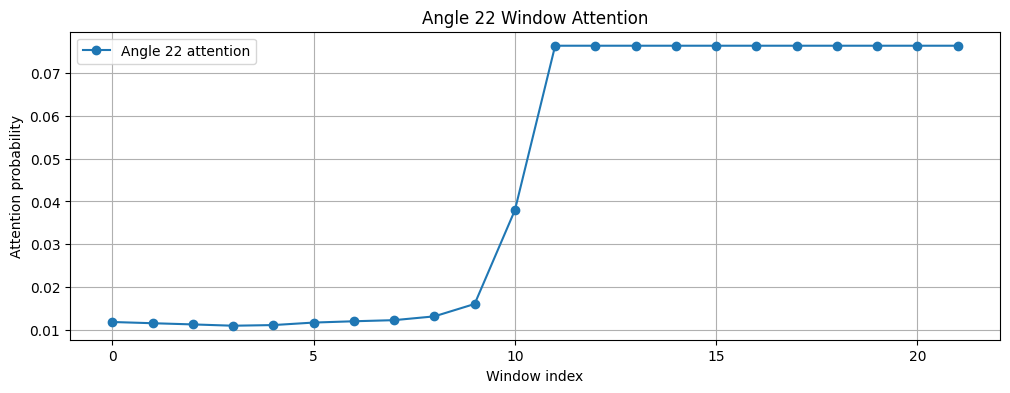


Training for angle 23...
Angle 23 | Epoch 001 | Loss 0.064674
Angle 23 | Epoch 002 | Loss 0.009187
Angle 23 | Epoch 003 | Loss 0.004864
Angle 23 | Epoch 004 | Loss 0.002554
Angle 23 | Epoch 005 | Loss 0.002084
Angle 23 | Epoch 006 | Loss 0.001494
Angle 23 | Epoch 007 | Loss 0.000254
Angle 23 | Epoch 008 | Loss 0.000151
Angle 23 | Epoch 009 | Loss 0.000380
Angle 23 | Epoch 010 | Loss 0.000354
Most important window for angle 23: 11


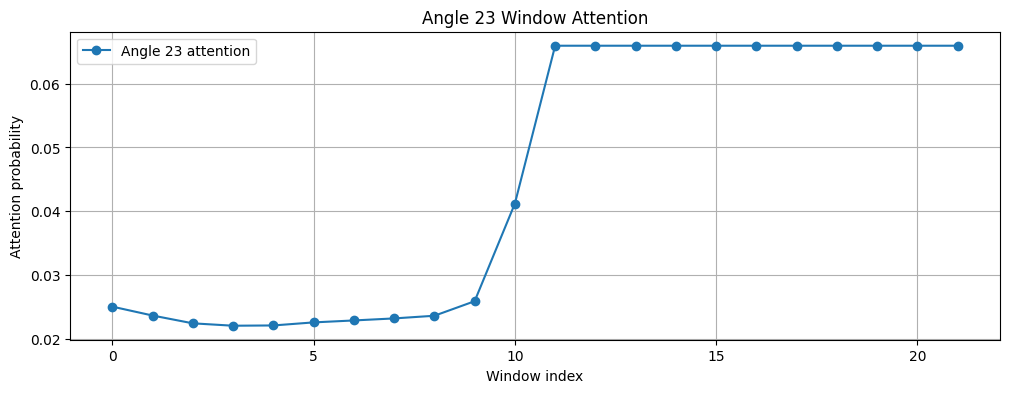


Training for angle 24...
Angle 24 | Epoch 001 | Loss 0.014808
Angle 24 | Epoch 002 | Loss 0.001103
Angle 24 | Epoch 003 | Loss 0.000459
Angle 24 | Epoch 004 | Loss 0.000401
Angle 24 | Epoch 005 | Loss 0.000269
Angle 24 | Epoch 006 | Loss 0.000174
Angle 24 | Epoch 007 | Loss 0.000509
Angle 24 | Epoch 008 | Loss 0.000533
Angle 24 | Epoch 009 | Loss 0.000341
Angle 24 | Epoch 010 | Loss 0.000165
Most important window for angle 24: 11


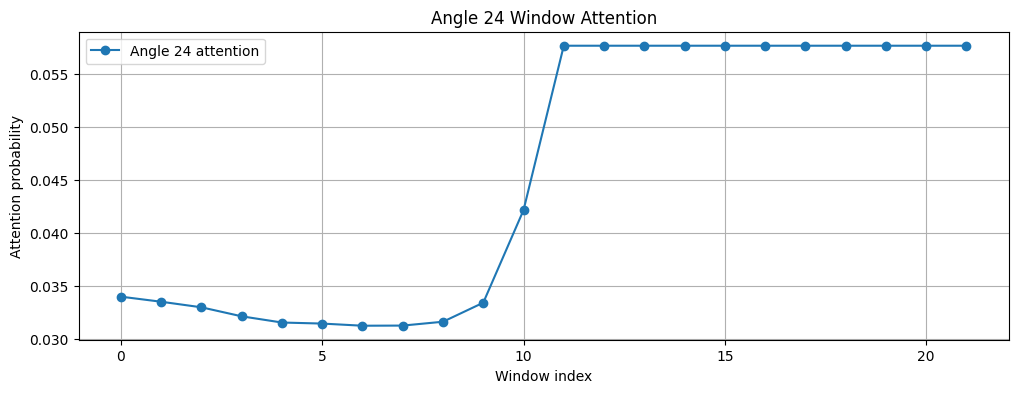


Training for angle 25...
Angle 25 | Epoch 001 | Loss 0.047908
Angle 25 | Epoch 002 | Loss 0.004398
Angle 25 | Epoch 003 | Loss 0.002332
Angle 25 | Epoch 004 | Loss 0.000769
Angle 25 | Epoch 005 | Loss 0.000206
Angle 25 | Epoch 006 | Loss 0.000316
Angle 25 | Epoch 007 | Loss 0.000083
Angle 25 | Epoch 008 | Loss 0.000202
Angle 25 | Epoch 009 | Loss 0.000266
Angle 25 | Epoch 010 | Loss 0.000110
Most important window for angle 25: 11


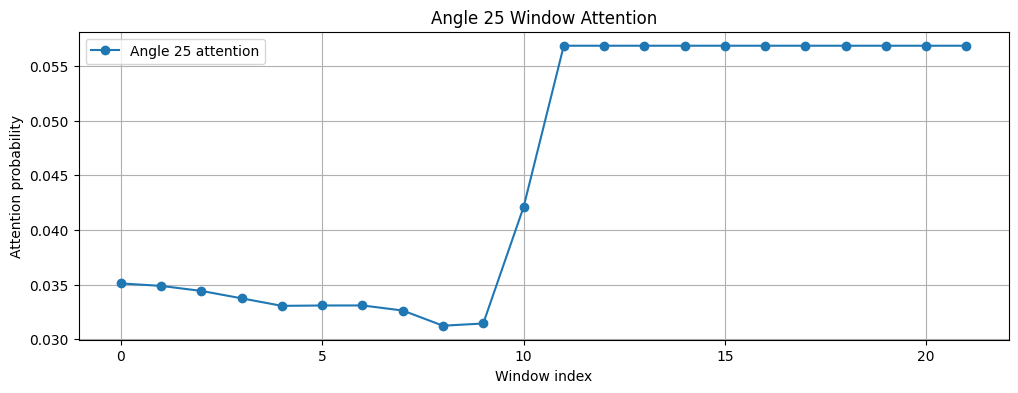


Training for angle 26...
Angle 26 | Epoch 001 | Loss 0.065684
Angle 26 | Epoch 002 | Loss 0.014522
Angle 26 | Epoch 003 | Loss 0.008879
Angle 26 | Epoch 004 | Loss 0.004791
Angle 26 | Epoch 005 | Loss 0.002432
Angle 26 | Epoch 006 | Loss 0.001449
Angle 26 | Epoch 007 | Loss 0.000972
Angle 26 | Epoch 008 | Loss 0.000610
Angle 26 | Epoch 009 | Loss 0.000544
Angle 26 | Epoch 010 | Loss 0.000280
Most important window for angle 26: 11


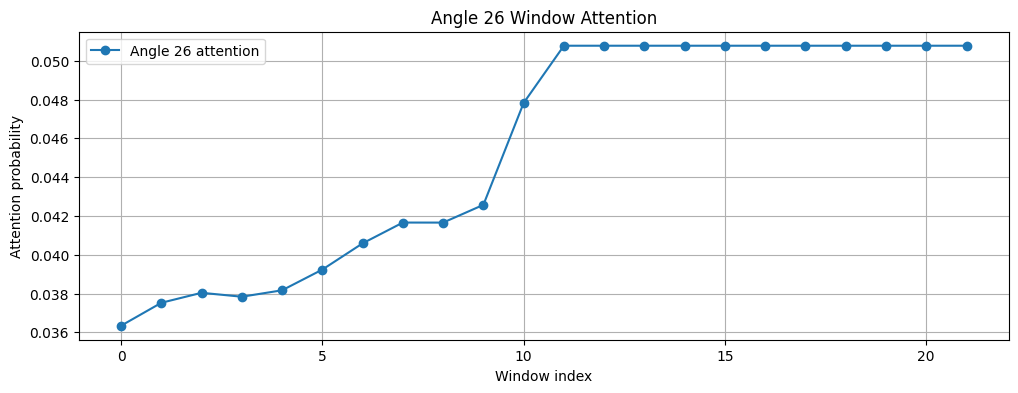


Training for angle 27...
Angle 27 | Epoch 001 | Loss 0.039357
Angle 27 | Epoch 002 | Loss 0.009474
Angle 27 | Epoch 003 | Loss 0.004683
Angle 27 | Epoch 004 | Loss 0.002162
Angle 27 | Epoch 005 | Loss 0.001229
Angle 27 | Epoch 006 | Loss 0.000221
Angle 27 | Epoch 007 | Loss 0.000173
Angle 27 | Epoch 008 | Loss 0.000228
Angle 27 | Epoch 009 | Loss 0.000328
Angle 27 | Epoch 010 | Loss 0.000373
Most important window for angle 27: 11


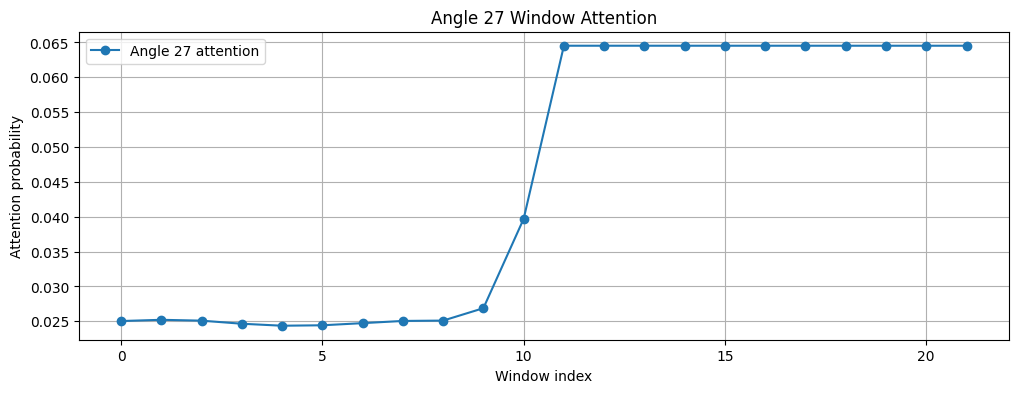


Training for angle 28...
Angle 28 | Epoch 001 | Loss 0.043653
Angle 28 | Epoch 002 | Loss 0.015587
Angle 28 | Epoch 003 | Loss 0.006397
Angle 28 | Epoch 004 | Loss 0.004709
Angle 28 | Epoch 005 | Loss 0.002921
Angle 28 | Epoch 006 | Loss 0.001924
Angle 28 | Epoch 007 | Loss 0.001143
Angle 28 | Epoch 008 | Loss 0.000503
Angle 28 | Epoch 009 | Loss 0.000352
Angle 28 | Epoch 010 | Loss 0.000305
Most important window for angle 28: 20


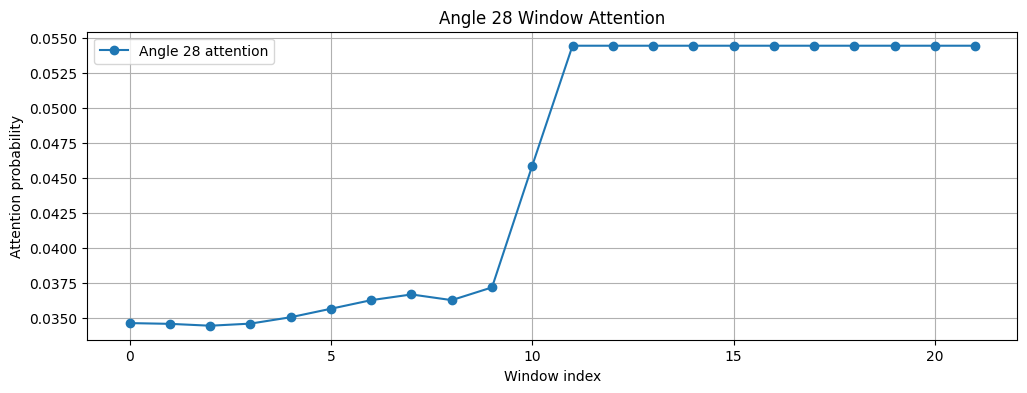


Training for angle 29...
Angle 29 | Epoch 001 | Loss 0.049801
Angle 29 | Epoch 002 | Loss 0.013532
Angle 29 | Epoch 003 | Loss 0.005925
Angle 29 | Epoch 004 | Loss 0.003406
Angle 29 | Epoch 005 | Loss 0.001908
Angle 29 | Epoch 006 | Loss 0.001087
Angle 29 | Epoch 007 | Loss 0.000489
Angle 29 | Epoch 008 | Loss 0.000260
Angle 29 | Epoch 009 | Loss 0.000293
Angle 29 | Epoch 010 | Loss 0.000270
Most important window for angle 29: 11


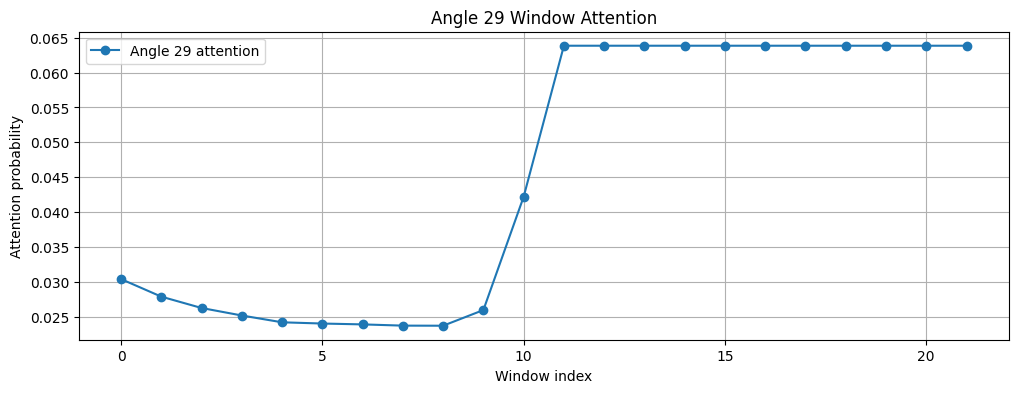


Training for angle 30...
Angle 30 | Epoch 001 | Loss 0.039198
Angle 30 | Epoch 002 | Loss 0.014506
Angle 30 | Epoch 003 | Loss 0.006718
Angle 30 | Epoch 004 | Loss 0.004749
Angle 30 | Epoch 005 | Loss 0.003212
Angle 30 | Epoch 006 | Loss 0.002029
Angle 30 | Epoch 007 | Loss 0.001164
Angle 30 | Epoch 008 | Loss 0.000708
Angle 30 | Epoch 009 | Loss 0.000499
Angle 30 | Epoch 010 | Loss 0.000256
Most important window for angle 30: 21


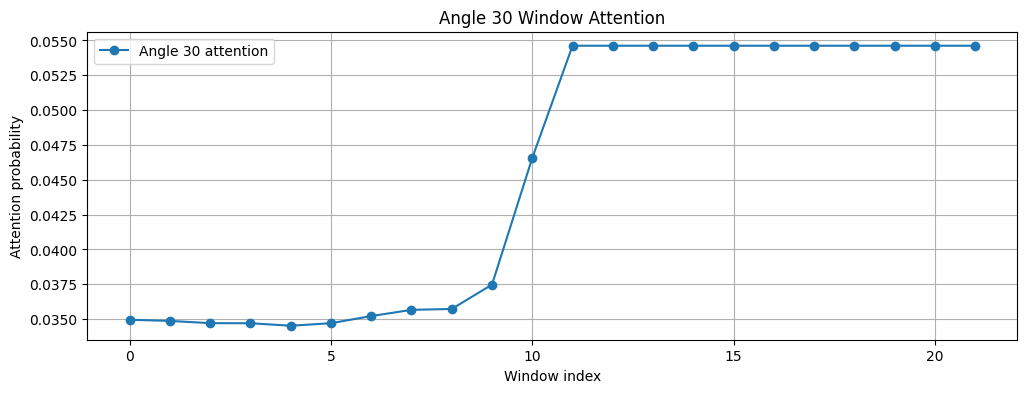


Training for angle 31...
Angle 31 | Epoch 001 | Loss 0.073632
Angle 31 | Epoch 002 | Loss 0.010130
Angle 31 | Epoch 003 | Loss 0.003680
Angle 31 | Epoch 004 | Loss 0.002207
Angle 31 | Epoch 005 | Loss 0.000998
Angle 31 | Epoch 006 | Loss 0.000608
Angle 31 | Epoch 007 | Loss 0.000554
Angle 31 | Epoch 008 | Loss 0.000407
Angle 31 | Epoch 009 | Loss 0.000543
Angle 31 | Epoch 010 | Loss 0.000667
Most important window for angle 31: 11


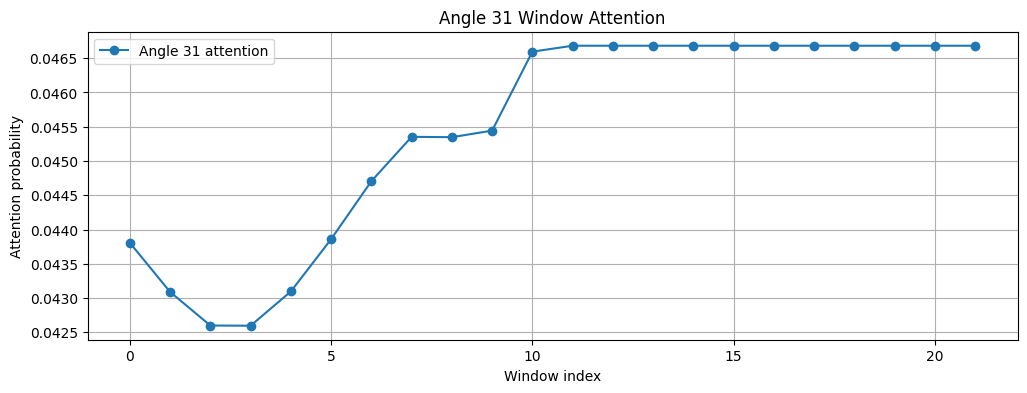


Training for angle 32...
Angle 32 | Epoch 001 | Loss 0.044982
Angle 32 | Epoch 002 | Loss 0.010518
Angle 32 | Epoch 003 | Loss 0.004300
Angle 32 | Epoch 004 | Loss 0.001887
Angle 32 | Epoch 005 | Loss 0.000491
Angle 32 | Epoch 006 | Loss 0.000470
Angle 32 | Epoch 007 | Loss 0.000541
Angle 32 | Epoch 008 | Loss 0.000429
Angle 32 | Epoch 009 | Loss 0.000143
Angle 32 | Epoch 010 | Loss 0.000132
Most important window for angle 32: 20


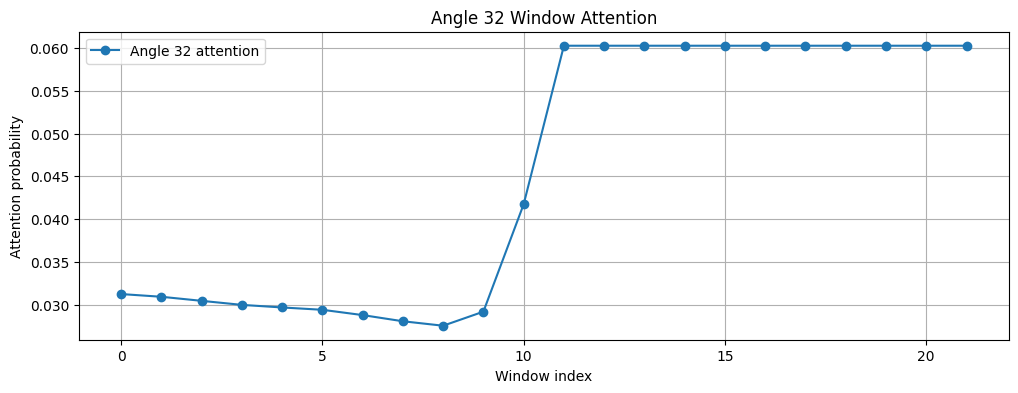


Training for angle 33...
Angle 33 | Epoch 001 | Loss 0.025446
Angle 33 | Epoch 002 | Loss 0.003976
Angle 33 | Epoch 003 | Loss 0.003043
Angle 33 | Epoch 004 | Loss 0.000686
Angle 33 | Epoch 005 | Loss 0.000623
Angle 33 | Epoch 006 | Loss 0.000239
Angle 33 | Epoch 007 | Loss 0.000338
Angle 33 | Epoch 008 | Loss 0.000451
Angle 33 | Epoch 009 | Loss 0.000246
Angle 33 | Epoch 010 | Loss 0.000286
Most important window for angle 33: 11


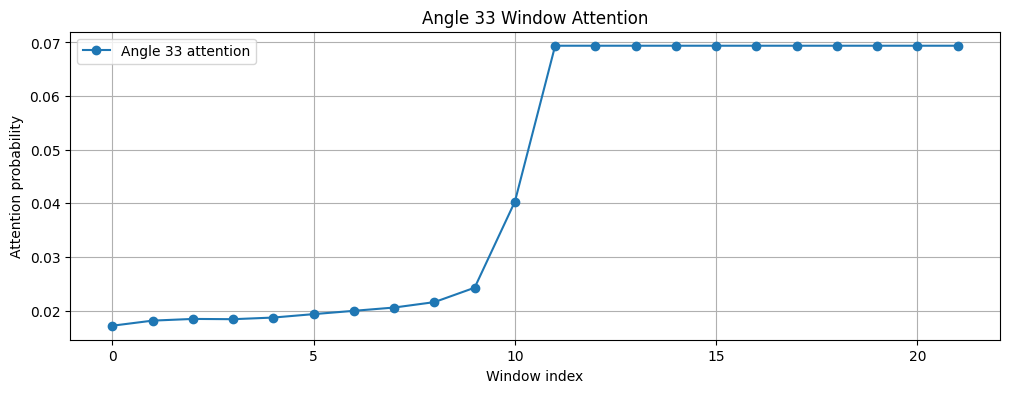


Training for angle 34...
Angle 34 | Epoch 001 | Loss 0.041516
Angle 34 | Epoch 002 | Loss 0.011973
Angle 34 | Epoch 003 | Loss 0.005103
Angle 34 | Epoch 004 | Loss 0.001960
Angle 34 | Epoch 005 | Loss 0.001555
Angle 34 | Epoch 006 | Loss 0.001549
Angle 34 | Epoch 007 | Loss 0.000751
Angle 34 | Epoch 008 | Loss 0.000753
Angle 34 | Epoch 009 | Loss 0.000323
Angle 34 | Epoch 010 | Loss 0.000560
Most important window for angle 34: 11


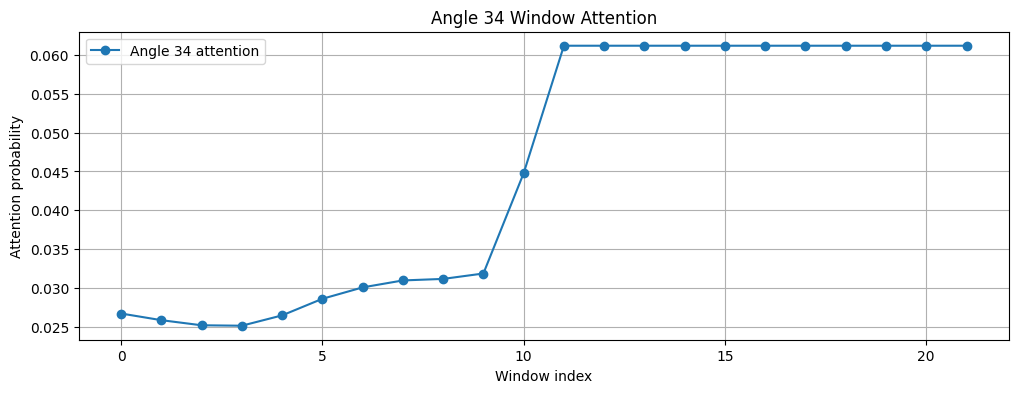


Training for angle 35...
Angle 35 | Epoch 001 | Loss 0.150532
Angle 35 | Epoch 002 | Loss 0.021438
Angle 35 | Epoch 003 | Loss 0.007651
Angle 35 | Epoch 004 | Loss 0.003439
Angle 35 | Epoch 005 | Loss 0.003726
Angle 35 | Epoch 006 | Loss 0.002358
Angle 35 | Epoch 007 | Loss 0.000723
Angle 35 | Epoch 008 | Loss 0.000253
Angle 35 | Epoch 009 | Loss 0.000739
Angle 35 | Epoch 010 | Loss 0.000514
Most important window for angle 35: 20


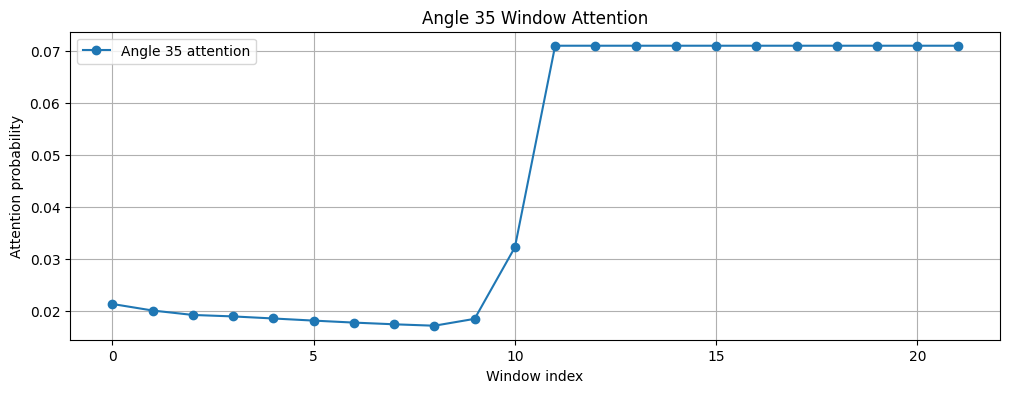


Training for angle 36...
Angle 36 | Epoch 001 | Loss 0.023714
Angle 36 | Epoch 002 | Loss 0.003346
Angle 36 | Epoch 003 | Loss 0.001516
Angle 36 | Epoch 004 | Loss 0.000767
Angle 36 | Epoch 005 | Loss 0.000907
Angle 36 | Epoch 006 | Loss 0.001228
Angle 36 | Epoch 007 | Loss 0.001435
Angle 36 | Epoch 008 | Loss 0.000935
Angle 36 | Epoch 009 | Loss 0.000515
Angle 36 | Epoch 010 | Loss 0.001007
Most important window for angle 36: 11


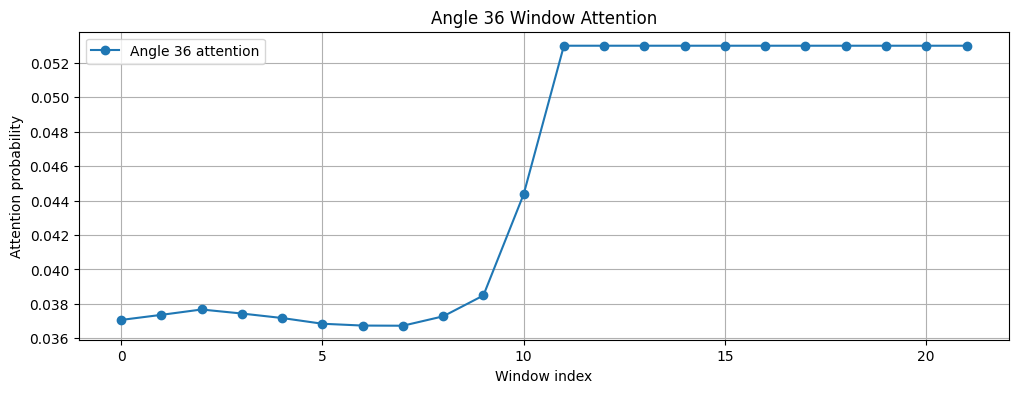


Training for angle 37...
Angle 37 | Epoch 001 | Loss 0.031941
Angle 37 | Epoch 002 | Loss 0.005490
Angle 37 | Epoch 003 | Loss 0.005178
Angle 37 | Epoch 004 | Loss 0.003144
Angle 37 | Epoch 005 | Loss 0.000627
Angle 37 | Epoch 006 | Loss 0.000428
Angle 37 | Epoch 007 | Loss 0.001272
Angle 37 | Epoch 008 | Loss 0.001165
Angle 37 | Epoch 009 | Loss 0.000316
Angle 37 | Epoch 010 | Loss 0.000495
Most important window for angle 37: 11


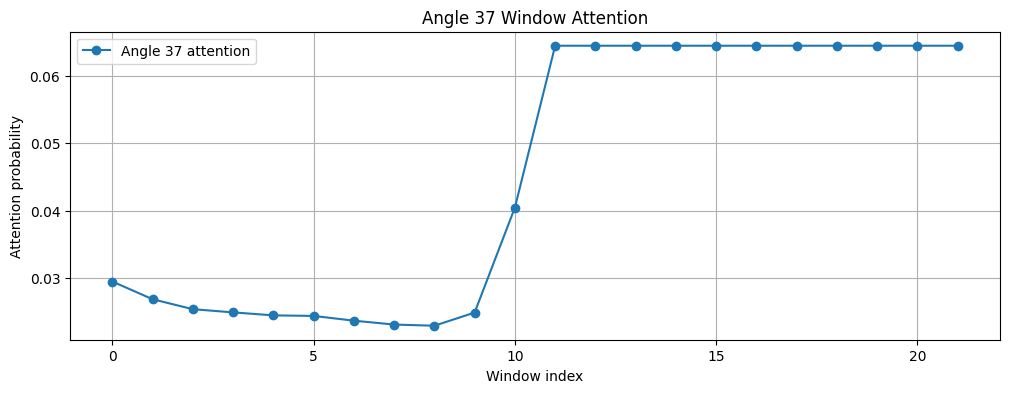


Training for angle 38...
Angle 38 | Epoch 001 | Loss 0.043893
Angle 38 | Epoch 002 | Loss 0.004686
Angle 38 | Epoch 003 | Loss 0.003746
Angle 38 | Epoch 004 | Loss 0.002738
Angle 38 | Epoch 005 | Loss 0.001221
Angle 38 | Epoch 006 | Loss 0.001684
Angle 38 | Epoch 007 | Loss 0.000400
Angle 38 | Epoch 008 | Loss 0.000630
Angle 38 | Epoch 009 | Loss 0.000612
Angle 38 | Epoch 010 | Loss 0.000426
Most important window for angle 38: 0


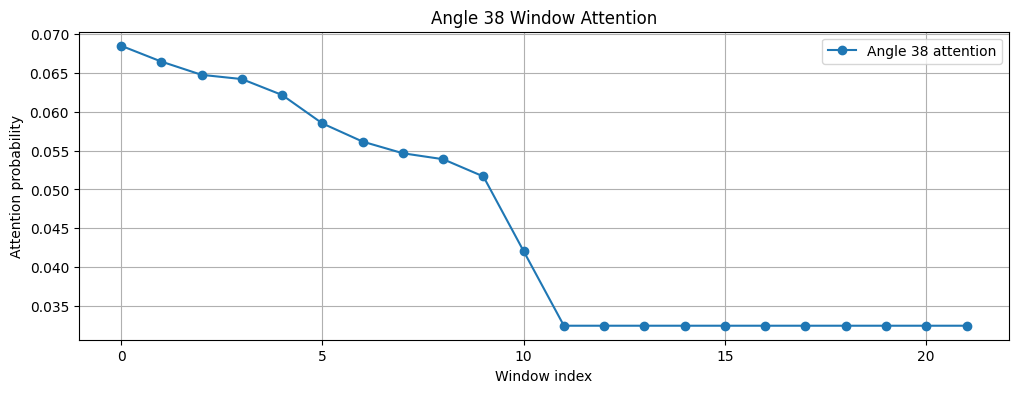


Training for angle 39...
Angle 39 | Epoch 001 | Loss 0.063494
Angle 39 | Epoch 002 | Loss 0.007380
Angle 39 | Epoch 003 | Loss 0.003568
Angle 39 | Epoch 004 | Loss 0.000572
Angle 39 | Epoch 005 | Loss 0.001809
Angle 39 | Epoch 006 | Loss 0.000702
Angle 39 | Epoch 007 | Loss 0.000644
Angle 39 | Epoch 008 | Loss 0.000504
Angle 39 | Epoch 009 | Loss 0.000444
Angle 39 | Epoch 010 | Loss 0.000402
Most important window for angle 39: 11


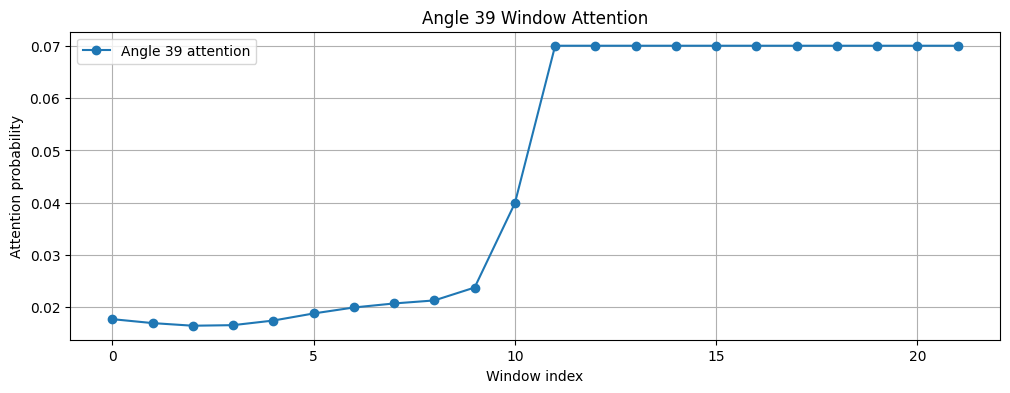


Training for angle 40...
Angle 40 | Epoch 001 | Loss 0.022906
Angle 40 | Epoch 002 | Loss 0.008109
Angle 40 | Epoch 003 | Loss 0.004549
Angle 40 | Epoch 004 | Loss 0.002166
Angle 40 | Epoch 005 | Loss 0.001352
Angle 40 | Epoch 006 | Loss 0.000560
Angle 40 | Epoch 007 | Loss 0.000895
Angle 40 | Epoch 008 | Loss 0.000658
Angle 40 | Epoch 009 | Loss 0.000385
Angle 40 | Epoch 010 | Loss 0.000826
Most important window for angle 40: 0


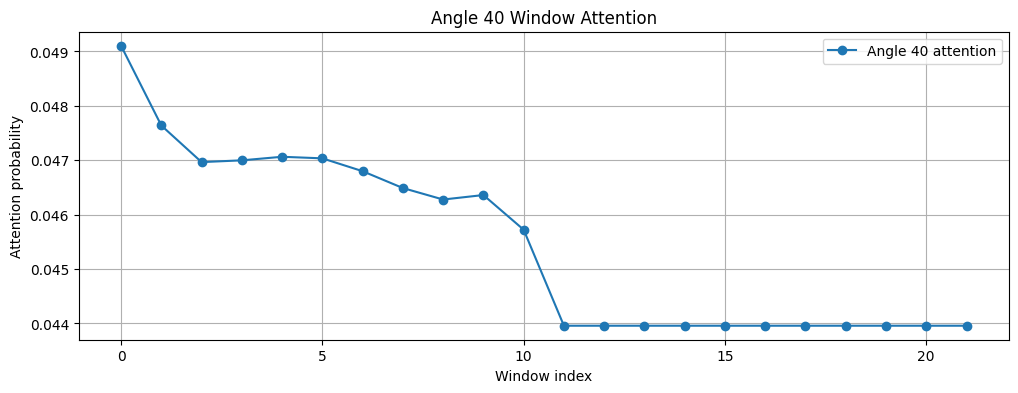


Training for angle 41...
Angle 41 | Epoch 001 | Loss 0.081014
Angle 41 | Epoch 002 | Loss 0.005219
Angle 41 | Epoch 003 | Loss 0.002147
Angle 41 | Epoch 004 | Loss 0.001261
Angle 41 | Epoch 005 | Loss 0.000500
Angle 41 | Epoch 006 | Loss 0.000399
Angle 41 | Epoch 007 | Loss 0.001234
Angle 41 | Epoch 008 | Loss 0.001247
Angle 41 | Epoch 009 | Loss 0.001854
Angle 41 | Epoch 010 | Loss 0.002364
Most important window for angle 41: 10


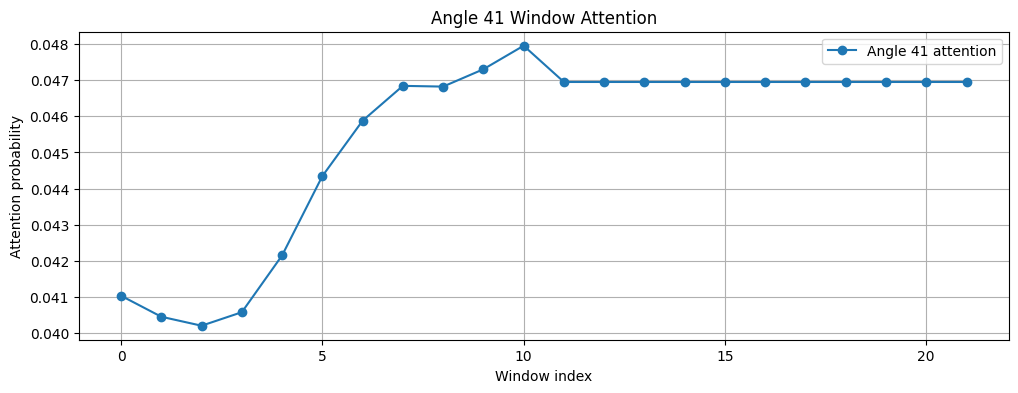


Training for angle 42...
Angle 42 | Epoch 001 | Loss 0.105255
Angle 42 | Epoch 002 | Loss 0.015447
Angle 42 | Epoch 003 | Loss 0.008689
Angle 42 | Epoch 004 | Loss 0.005323
Angle 42 | Epoch 005 | Loss 0.002439
Angle 42 | Epoch 006 | Loss 0.002100
Angle 42 | Epoch 007 | Loss 0.000492
Angle 42 | Epoch 008 | Loss 0.000824
Angle 42 | Epoch 009 | Loss 0.000625
Angle 42 | Epoch 010 | Loss 0.000952
Most important window for angle 42: 11


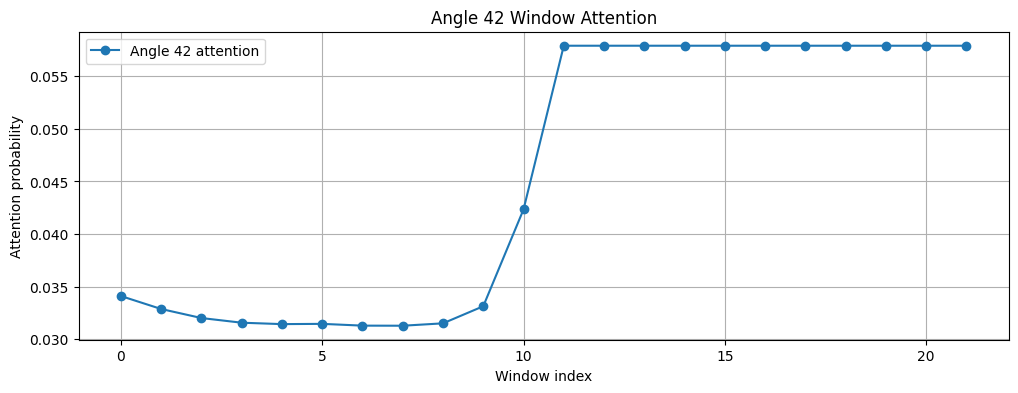


Training for angle 43...
Angle 43 | Epoch 001 | Loss 0.033488
Angle 43 | Epoch 002 | Loss 0.007829
Angle 43 | Epoch 003 | Loss 0.001909
Angle 43 | Epoch 004 | Loss 0.000875
Angle 43 | Epoch 005 | Loss 0.001712
Angle 43 | Epoch 006 | Loss 0.000888
Angle 43 | Epoch 007 | Loss 0.001147
Angle 43 | Epoch 008 | Loss 0.000885
Angle 43 | Epoch 009 | Loss 0.001152
Angle 43 | Epoch 010 | Loss 0.001012
Most important window for angle 43: 11


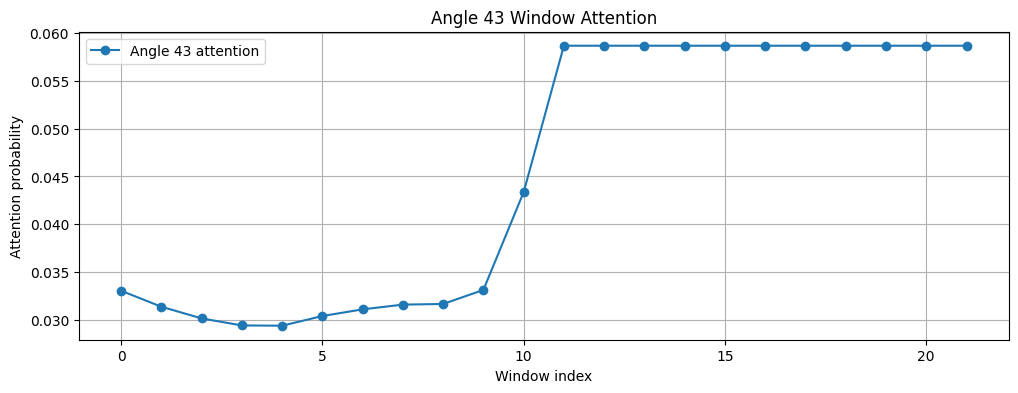


Training for angle 44...
Angle 44 | Epoch 001 | Loss 0.054801
Angle 44 | Epoch 002 | Loss 0.016300
Angle 44 | Epoch 003 | Loss 0.008420
Angle 44 | Epoch 004 | Loss 0.008095
Angle 44 | Epoch 005 | Loss 0.003333
Angle 44 | Epoch 006 | Loss 0.001137
Angle 44 | Epoch 007 | Loss 0.001783
Angle 44 | Epoch 008 | Loss 0.000651
Angle 44 | Epoch 009 | Loss 0.000858
Angle 44 | Epoch 010 | Loss 0.000897
Most important window for angle 44: 11


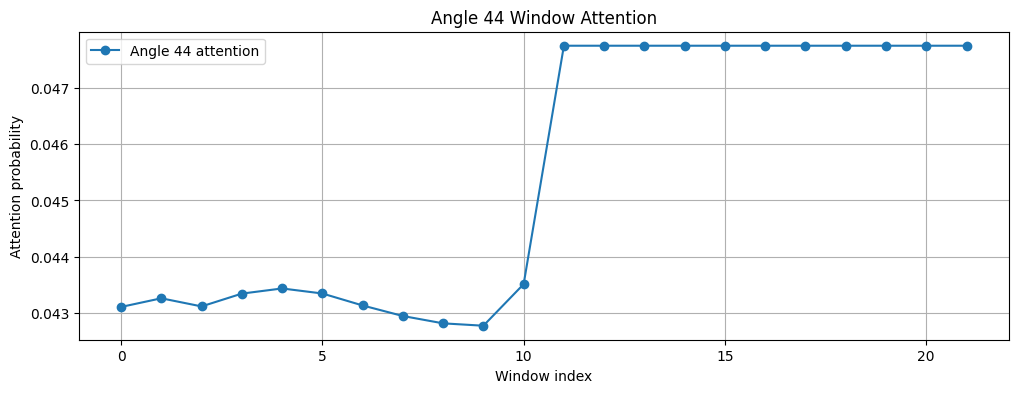


Training for angle 45...
Angle 45 | Epoch 001 | Loss 0.130325
Angle 45 | Epoch 002 | Loss 0.014641
Angle 45 | Epoch 003 | Loss 0.013795
Angle 45 | Epoch 004 | Loss 0.008541
Angle 45 | Epoch 005 | Loss 0.000695
Angle 45 | Epoch 006 | Loss 0.003110
Angle 45 | Epoch 007 | Loss 0.001068
Angle 45 | Epoch 008 | Loss 0.001083
Angle 45 | Epoch 009 | Loss 0.001038
Angle 45 | Epoch 010 | Loss 0.000554
Most important window for angle 45: 2


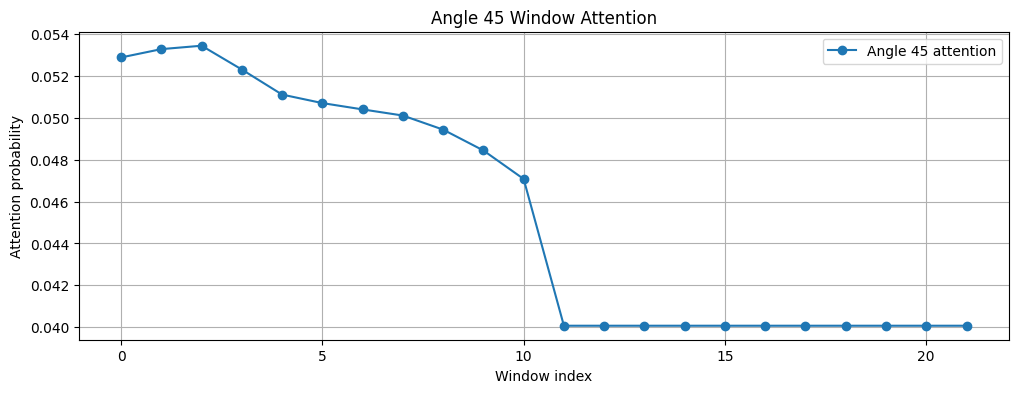


Training for angle 46...
Angle 46 | Epoch 001 | Loss 0.052985
Angle 46 | Epoch 002 | Loss 0.016841
Angle 46 | Epoch 003 | Loss 0.011431
Angle 46 | Epoch 004 | Loss 0.005461
Angle 46 | Epoch 005 | Loss 0.001551
Angle 46 | Epoch 006 | Loss 0.002353
Angle 46 | Epoch 007 | Loss 0.000808
Angle 46 | Epoch 008 | Loss 0.000457
Angle 46 | Epoch 009 | Loss 0.000494
Angle 46 | Epoch 010 | Loss 0.000166
Most important window for angle 46: 11


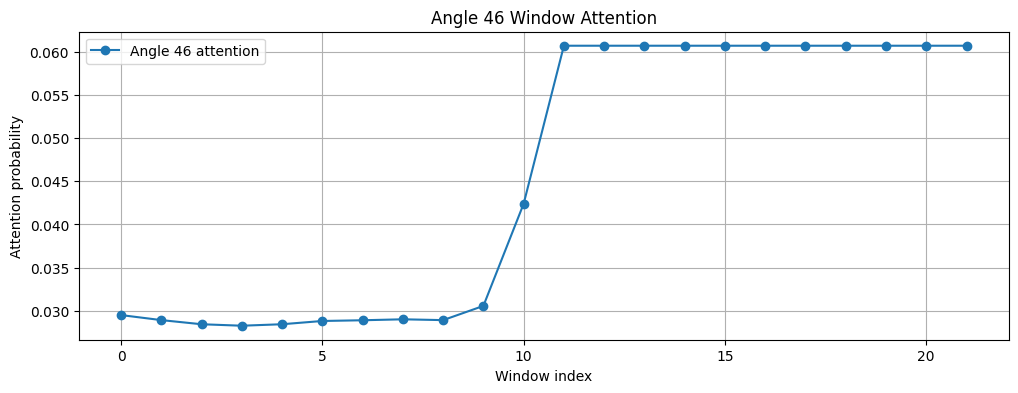

In [13]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

# ---------------- Sliding Window ----------------
def sliding_windows(X: np.ndarray, window_size: int, stride: int) -> np.ndarray:
    T, F = X.shape
    windows = []
    for start in range(0, T - window_size + 1, stride):
        windows.append(X[start:start + window_size])
    return np.stack(windows, axis=0)

# ---------------- Dataset per angle ----------------
class WindowedAngleDataset(Dataset):
    def __init__(self, X, Y, angle_idx, window_size=150, stride=75):
        """
        X: (n_experiments, T, F)
        Y: (n_experiments, n_angles, 1)
        angle_idx: index of angle to model
        """
        self.items = []
        for i in range(X.shape[0]):
            Ws = sliding_windows(X[i], window_size, stride)  # (n_windows, W, F)
            target = Y[i].squeeze(-1)[angle_idx]            # fixed line: scalar target for this angle
            self.items.append((Ws, target))

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        windows, target = self.items[idx]
        return torch.tensor(windows, dtype=torch.float32), torch.tensor(target, dtype=torch.float32)

# ---------------- Model ----------------
class WindowEncoder(nn.Module):
    def __init__(self, in_features: int, hidden_dim: int = 64, emb_dim: int = 128):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=in_features, hidden_size=hidden_dim,
            batch_first=True, bidirectional=True
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, emb_dim),
            nn.ReLU(),
            nn.LayerNorm(emb_dim),
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        pooled = out.mean(dim=1)
        return self.fc(pooled)

class SequenceAttentionRegressor(nn.Module):
    def __init__(self, in_features=17, window_hidden=64, window_emb=128):
        super().__init__()
        self.window_encoder = WindowEncoder(in_features, hidden_dim=window_hidden, emb_dim=window_emb)
        self.attn = nn.Sequential(
            nn.Linear(window_emb, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )
        self.regressor = nn.Sequential(
            nn.Linear(window_emb, window_emb // 2),
            nn.ReLU(),
            nn.Linear(window_emb // 2, 1)
        )

    def forward(self, windows_batch):
        B, N, W, F = windows_batch.shape
        x = windows_batch.view(B * N, W, F)
        emb = self.window_encoder(x)           # (B*N, emb)
        emb = emb.view(B, N, -1)               # (B, N, emb)
        scores = self.attn(emb).squeeze(-1)    # (B, N)
        attn_weights = torch.softmax(scores, dim=1)
        weighted = (attn_weights.unsqueeze(-1) * emb).sum(dim=1)
        preds = self.regressor(weighted).squeeze(-1)  # (B,)
        return preds, attn_weights

# ---------------- Train one angle ----------------
def train_angle_model(X, Y, angle_idx, window_size=150, stride=75, epochs=20, batch_size=1, device='cpu'):
    dataset = WindowedAngleDataset(X, Y, angle_idx, window_size, stride)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    model = SequenceAttentionRegressor(in_features=X.shape[2]).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0
        for windows, target in loader:
            windows, target = windows.to(device), target.to(device)
            preds, attn = model(windows)
            loss = loss_fn(preds, target)
            opt.zero_grad()
            loss.backward()
            opt.step()
            total_loss += loss.item() * windows.size(0)
        avg_loss = total_loss / len(loader.dataset)
        print(f"Angle {angle_idx} | Epoch {epoch:03d} | Loss {avg_loss:.6f}")
    return model

# ---------------- Get attention for one experiment ----------------
def get_window_attention(model, X_exp, window_size=150, stride=75, device='cpu'):
    Ws = sliding_windows(X_exp, window_size, stride)
    inp = torch.tensor(Ws[None, ...], dtype=torch.float32).to(device)
    model.eval()
    with torch.no_grad():
        preds, attn = model(inp)
    return preds.cpu().numpy().squeeze(), attn.cpu().numpy().squeeze()

# ---------------- Visualization ----------------
def plot_window_attention(attn_weights, angle_idx=0, title="Window Attention"):
    n_windows = len(attn_weights)
    plt.figure(figsize=(12,4))
    plt.plot(range(n_windows), attn_weights, 'o-', label=f'Angle {angle_idx} attention')
    plt.xlabel('Window index')
    plt.ylabel('Attention probability')
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()

# ---------------- Main ----------------
if __name__ == "__main__":
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    n_angles = Y.shape[1]

    best_windows = []

    for angle_idx in range(n_angles):
        print(f"\nTraining for angle {angle_idx}...")
        model = train_angle_model(X, Y, angle_idx, window_size=150, stride=75, epochs=10, device=device)

        # Get attention for first experiment
        preds, attn_weights = get_window_attention(model, X[0], window_size=150, stride=75, device=device)
        best_window_idx = np.argmax(attn_weights)
        print(f"Most important window for angle {angle_idx}: {best_window_idx}")
        best_windows.append(best_window_idx)

        # Visualize attention
        plot_window_attention(attn_weights, angle_idx=angle_idx, title=f"Angle {angle_idx} Window Attention")


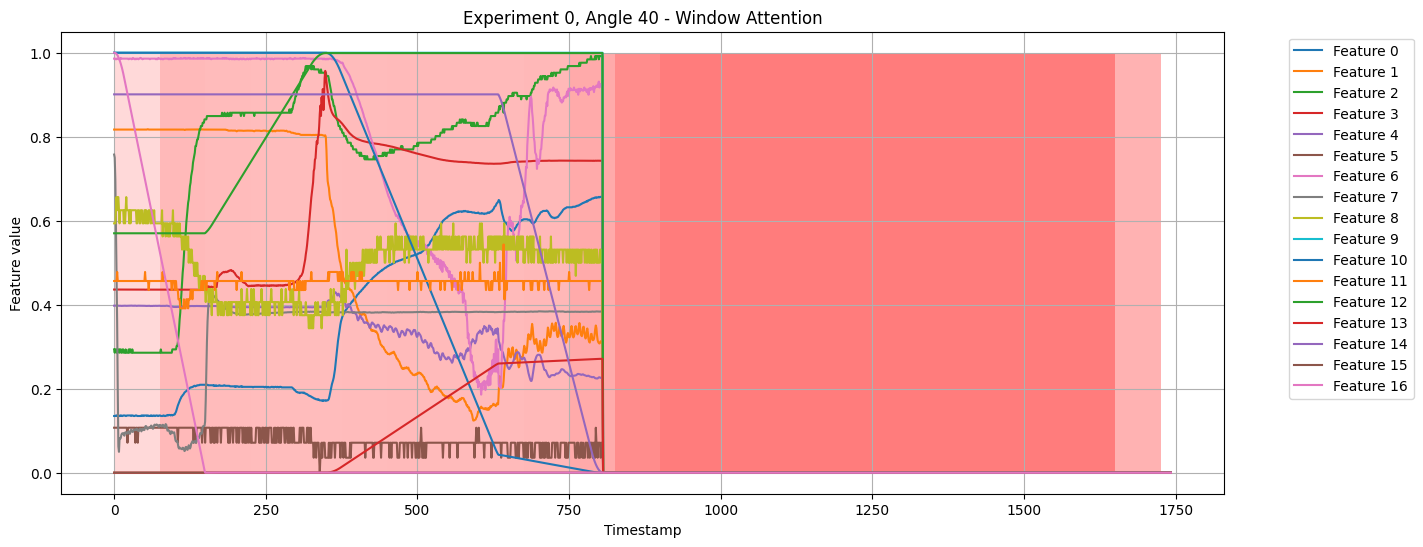

In [23]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def plot_X_with_window_attention(X_exp, attn_weights, window_size=150, stride=75, title="X features with window attention"):
    """
    X_exp: (T, F) - experiment features
    attn_weights: (n_windows,) - attention per window
    """
    T, F = X_exp.shape
    n_windows = len(attn_weights)
    
    fig, ax = plt.subplots(figsize=(15,6))
    
    # Plot all 17 features as lines
    for f in range(F):
        ax.plot(range(T), X_exp[:, f], label=f'Feature {f}')
    
    # Add window rectangles with alpha proportional to attention
    for i, start in enumerate(range(0, T - window_size + 1, stride)):
        rect = patches.Rectangle((start, np.min(X_exp)), window_size, np.max(X_exp)-np.min(X_exp),
                                 linewidth=0, facecolor='red', alpha=attn_weights[i]*5)
        ax.add_patch(rect)
    
    ax.set_xlabel('Timestamp')
    ax.set_ylabel('Feature value')
    ax.set_title(title)
    ax.grid(True)
    ax.legend(bbox_to_anchor=(1.05,1), loc='upper left')
    plt.show()

# Choose experiment and angle
exp_idx = 0
angle_idx = 40

# Get attention for the angle
preds, attn_weights = get_window_attention(model, X[exp_idx], window_size=150, stride=75, device='cpu')

# Plot X features with **window-level attention**
plot_X_with_window_attention(X[exp_idx], attn_weights, window_size=150, stride=75,
                             title=f"Experiment {exp_idx}, Angle {angle_idx} - Window Attention")

